# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# Installing and Importing Libraries

In [1]:
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [634 lines of output]
      + /opt/homebrew/Caskroom/miniconda/base/bin/python /private/var/folders/lh/hwy80zk51qq7ws4gkhw6vlrw0000gn/T/pip-install-zfenlytf/numpy_b5fa501ac5364c1d8472afde3cef1e14/vendored-meson/meson/meson.py setup /private/var/folders/lh/hwy80zk51qq7ws4gkhw6vlrw0000gn/T/pip-install-zfenlytf/numpy_b5fa501ac5364c1d8472afde3cef1e14 /private/var/folders/lh/hwy80zk51qq7ws4gkhw6vlrw0000gn/T/pip-install-zfenlytf/numpy_b5fa501ac5364c1d8472afde3cef1e14/.mesonpy-29f0hkge -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=/private/var/folders/lh/hwy80zk51qq7ws4gkhw6vlrw0000gn/T/pip-install-zfenlytf/numpy_b5fa501ac5364c1d8472afde3cef1e14/.mesonpy-29f0hkge/meson-python-native-file.ini
      The Meson build system
      Version: 1.4.99
      Source dir: /private/var/folders/lh/hwy80zk51qq7ws4gkhw6vlrw0000gn/T/pip-install-zfenlytf/numpy_

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import requests
from huggingface_hub import login, HfApi, create_repo

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
sns.set_palette('muted')

print('Ready.')

Ready.


# Loading the Dataset

In [3]:
kart = pd.read_csv('SuperKart.csv')
data = kart.copy()
print(f'{data.shape[0]:,} rows × {data.shape[1]} columns')

8,763 rows × 12 columns


# Data Overview

In [4]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [5]:
data.tail()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


In [6]:
print(f'{data.shape[0]:,} rows, {data.shape[1]} columns')

8,763 rows, 12 columns


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   str    
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   str    
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   str    
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   str    
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   str    
 9   Store_Location_City_Type   8763 non-null   str    
 10  Store_Type                 8763 non-null   str    
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 821.7 KB


In [8]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,8763,8763,FD6114,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,8763.0,NaN,NaN,NaN,12.653792,2.21732,4.0,11.15,12.66,14.18,22.0
Product_Sugar_Content,8763,4,Low Sugar,4885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,8763.0,NaN,NaN,NaN,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_Type,8763,16,Fruits and Vegetables,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,8763.0,NaN,NaN,NaN,147.032539,30.69411,31.0,126.16,146.74,167.585,266.0
Store_Id,8763,4,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,8763.0,NaN,NaN,NaN,2002.032751,8.388381,1987.0,1998.0,2009.0,2009.0,2009.0
Store_Size,8763,3,Medium,6025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,8763,3,Tier 2,6262,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Zero nulls anywhere
data.isnull().sum()

Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

In [10]:
data.duplicated().sum()

np.int64(0)

**Data integrity check:**

The dataset is clean. There are no nulls in any of the 12 columns and no duplicate rows.

`Product_Id` has 8,763 unique values, one per row, so it is a surrogate key that identifies rows rather than describing them. I drop it.

The four store-level columns — `Store_Establishment_Year`, `Store_Size`, `Store_Location_City_Type`, and `Store_Type` — are fixed by `Store_Id`. Each of the 4 stores has exactly one value for each of these attributes, with no variation. So all four hold the same four-group structure as `Store_Id`. Keeping all five together is redundant; encoding any one of them recovers the rest.

In [11]:
# Verify perfect determinism of store attributes
for col in ['Store_Establishment_Year','Store_Size','Store_Location_City_Type','Store_Type']:
    max_unique = data.groupby('Store_Id')[col].nunique().max()
    print(f'{col}: max distinct values within any Store_Id = {max_unique}')

Store_Establishment_Year: max distinct values within any Store_Id = 1
Store_Size: max distinct values within any Store_Id = 1
Store_Location_City_Type: max distinct values within any Store_Id = 1
Store_Type: max distinct values within any Store_Id = 1


In [12]:
# The 4 store profiles in full
data.drop_duplicates('Store_Id')[
    ['Store_Id','Store_Type','Store_Location_City_Type','Store_Size','Store_Establishment_Year']
].set_index('Store_Id').sort_index()

,Store_Type,Store_Location_City_Type,Store_Size,Store_Establishment_Year
Store_Id,,,,
OUT001,Supermarket Type1,Tier 2,High,1987
OUT002,Food Mart,Tier 3,Small,1998
OUT003,Departmental Store,Tier 1,Medium,1999
OUT004,Supermarket Type2,Tier 2,Medium,2009


# Exploratory Data Analysis

## Univariate Analysis

In [13]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    f, (ax_box, ax_hist) = plt.subplots(
        nrows=2, sharex=True,
        gridspec_kw={'height_ratios': (0.25, 0.75)}, figsize=figsize
    )
    sns.boxplot(data=data, x=feature, ax=ax_box, showmeans=True, color='steelblue')
    ax_box.set(xlabel='')
    if bins:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist, bins=bins)
    else:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist)
    ax_hist.axvline(data[feature].mean(), color='firebrick', linestyle='--', lw=1.5, label=f'Mean={data[feature].mean():.1f}')
    ax_hist.axvline(data[feature].median(), color='black', linestyle='-', lw=1.5, label=f'Median={data[feature].median():.1f}')
    ax_hist.legend(fontsize=10)
    plt.suptitle(feature, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

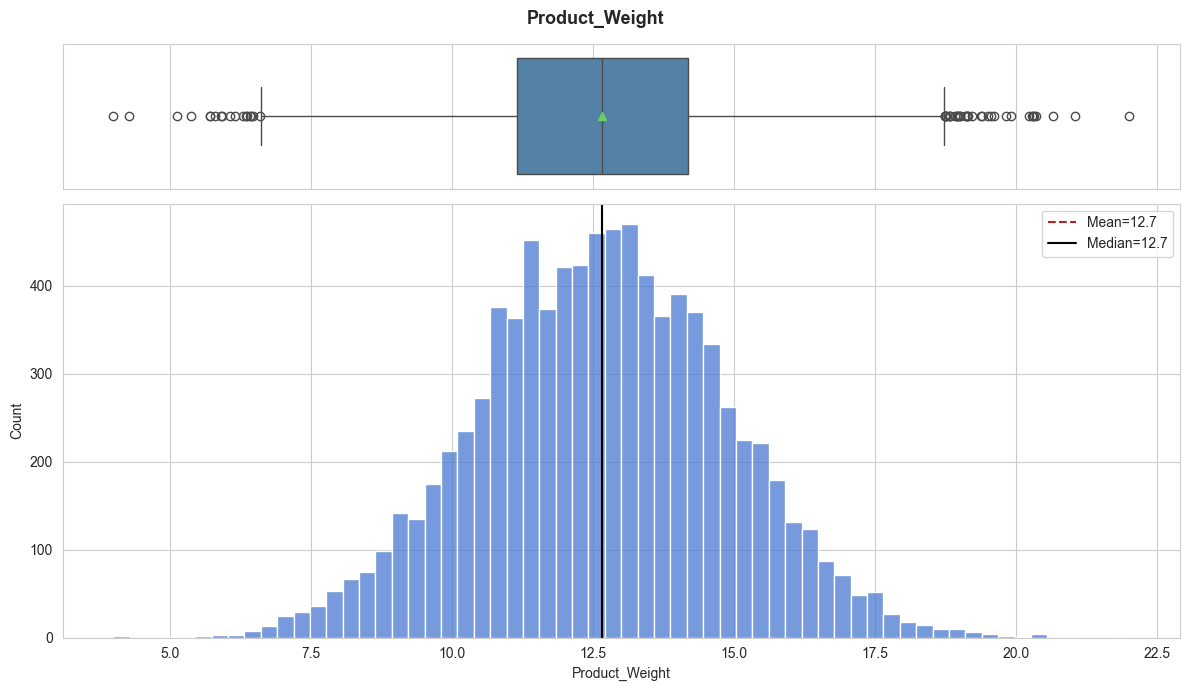

In [14]:
histogram_boxplot(data, 'Product_Weight')

**Product_Weight** is roughly symmetric (mean 12.65, median 12.66). The IQR runs from 11.15 to 14.18 kg, and the values up to 22 kg look like real products, not errors, so no imputation is needed. Its global correlation with the target is r = 0.74, but that figure changes a lot by store. The weight signal is mostly standing in for store-level pricing rather than a real weight-to-revenue link.

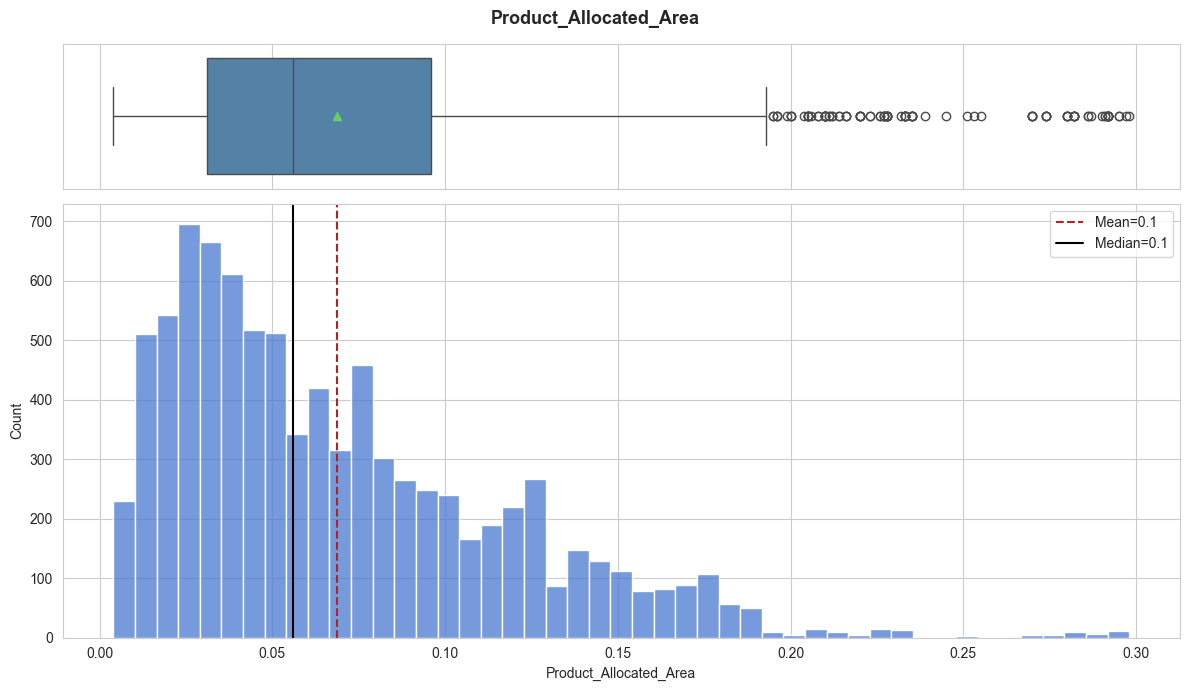

In [15]:
histogram_boxplot(data, 'Product_Allocated_Area')

**Product_Allocated_Area** is right-skewed, with 163 values near zero (below 0.01). Its correlation with `Product_Store_Sales_Total` is r = −0.001 — effectively nothing. Shelf-space ratio as recorded here tells us nothing about revenue, so I drop it to cut noise.

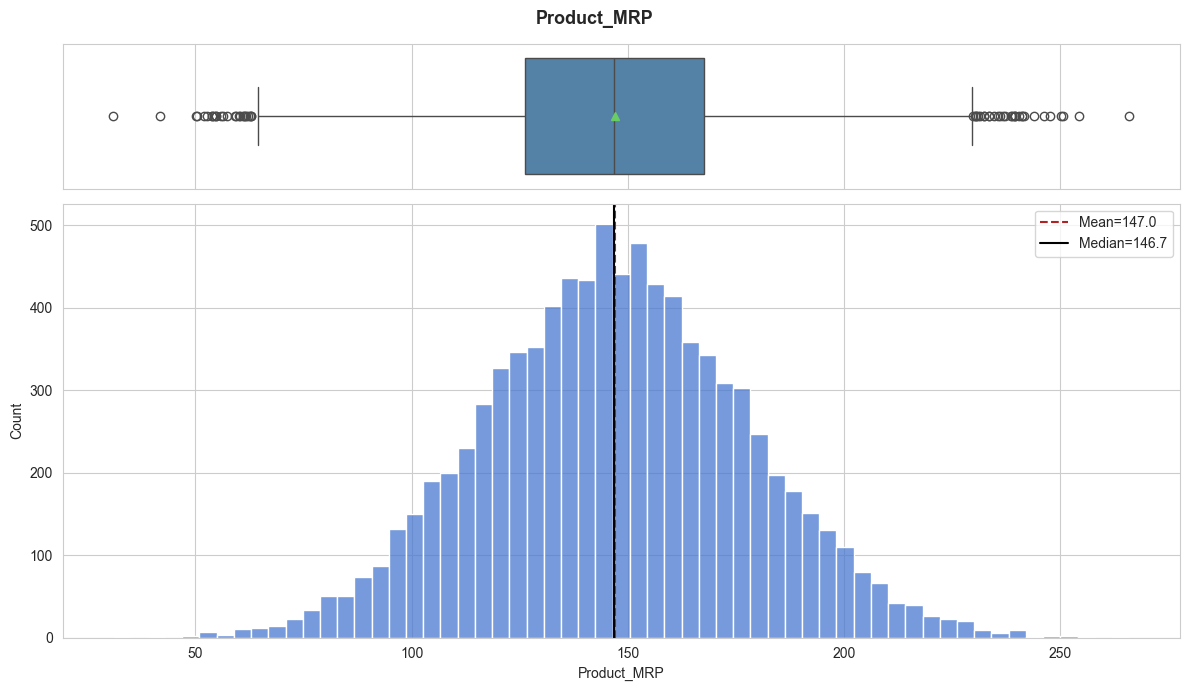

In [16]:
histogram_boxplot(data, 'Product_MRP')

**Product_MRP** is the strongest single numeric predictor, with a global correlation of r = 0.79. The IQR is narrow ($126–$168) around a mean of $147. The relationship is not the same across stores, though: r = 0.82 in OUT001 versus r = 0.15 in OUT002. This store-by-store difference is the main reason a linear model struggles and tree ensembles do better.

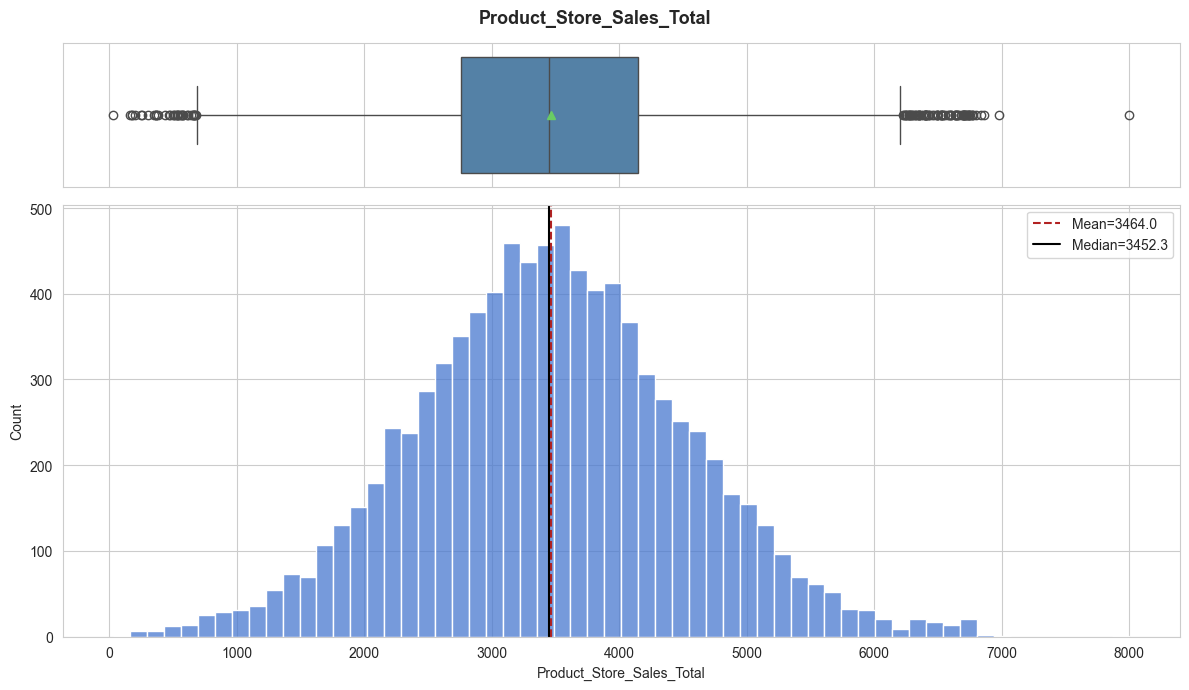

In [17]:
histogram_boxplot(data, 'Product_Store_Sales_Total')

**Product_Store_Sales_Total** ranges from $33 to $8,000, with a mean of $3,464 and a standard deviation of $1,066. Splitting by store shows the distribution is really two or more clusters stacked together — OUT002 centres near $1,763 while OUT003 centres near $4,947. The overall distribution is a mix of four narrower store-level distributions.

In [18]:
def labeled_barplot(data, feature, perc=False, n=None):
    total = len(data[feature])
    count = data[feature].nunique()
    figsize = (max(count + 1, 6), 5) if n is None else (max(n + 1, 6), 5)
    plt.figure(figsize=figsize)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    ax = sns.countplot(
        data=data, x=feature,
        order=data[feature].value_counts().index[:n].sort_values()
    )
    for p in ax.patches:
        label = f'{100 * p.get_height() / total:.1f}%' if perc else int(p.get_height())
        ax.annotate(label, (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', size=11)
    plt.title(feature, fontweight='bold')
    plt.tight_layout()
    plt.show()

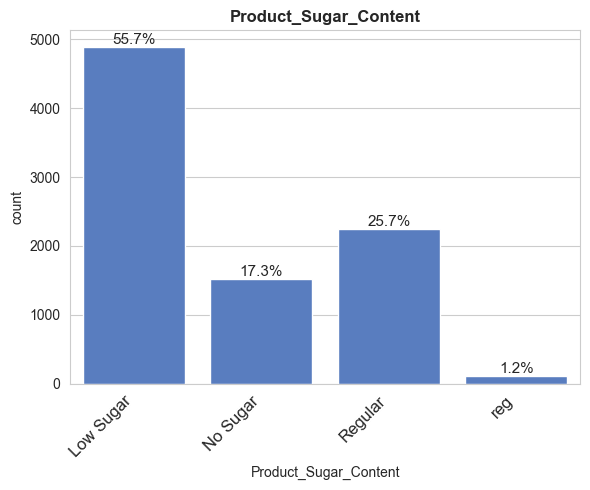

In [19]:
labeled_barplot(data, 'Product_Sugar_Content', perc=True)

**Product_Sugar_Content:** Low Sugar is the largest group at 55.7% (4,885 SKUs). Regular is 25.7% (2,251) and No Sugar is 17.3% (1,519). The `reg` label (1.2%, 108 rows) is just a misspelt version of `Regular`, which I fix in preprocessing. These proportions are driven mostly by OUT004's large catalogue (4,676 SKUs); split by store, the shares move around.

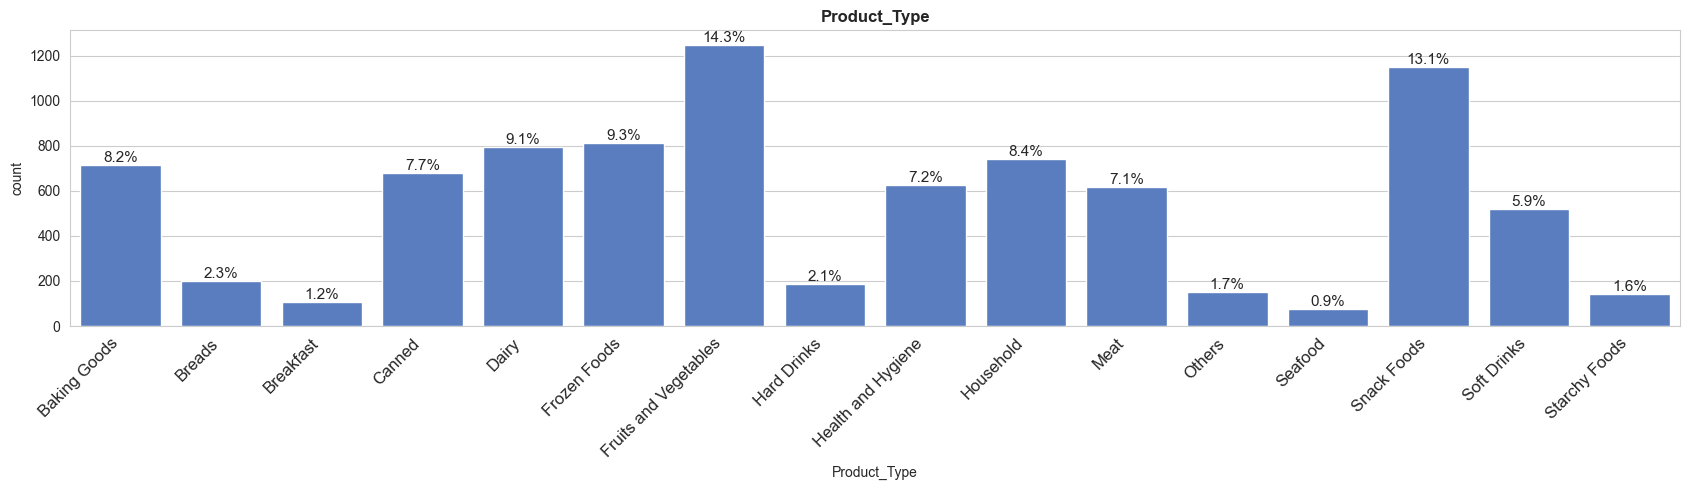

In [20]:
labeled_barplot(data, 'Product_Type', perc=True)

**Product_Type:** Fruits & Vegetables (1,249) and Snack Foods (1,149) are the biggest categories by count. But average sales across all 16 types only span $315 ($3,365 for Hard Drinks up to $3,679 for Starchy Foods). So product type is a weak predictor of revenue — which store a product sits in matters far more than its category.

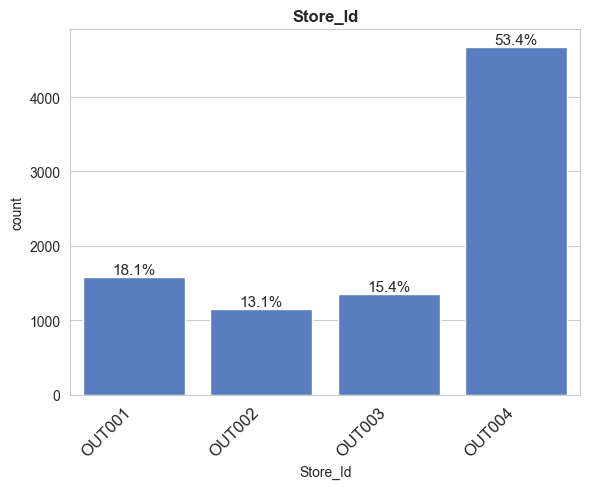

In [21]:
labeled_barplot(data, 'Store_Id', perc=True)

**Store_Id** counts are dominated by OUT004 with 4,676 SKUs, or 53.4% of the data. OUT001 has 1,586, OUT003 has 1,349, and OUT002 has 1,152. Each product appears in exactly one store, so `Product_Id` is split across stores, not shared. That makes `Store_Id` a real attribute of each row rather than a join key.

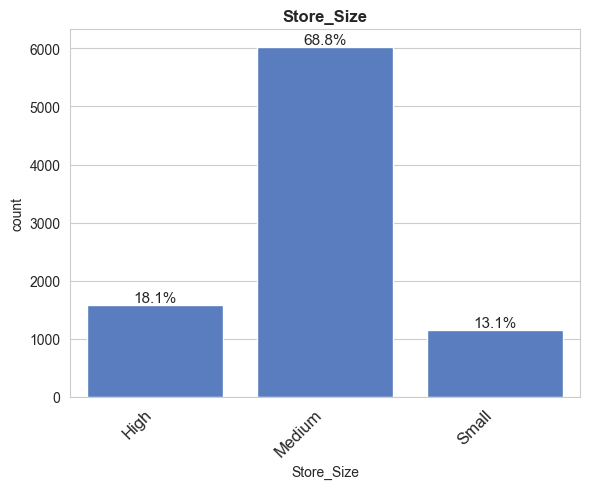

In [22]:
labeled_barplot(data, 'Store_Size', perc=True)

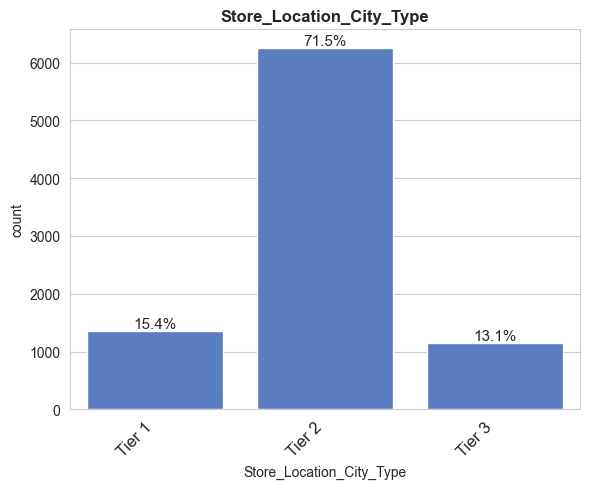

In [23]:
labeled_barplot(data, 'Store_Location_City_Type', perc=True)

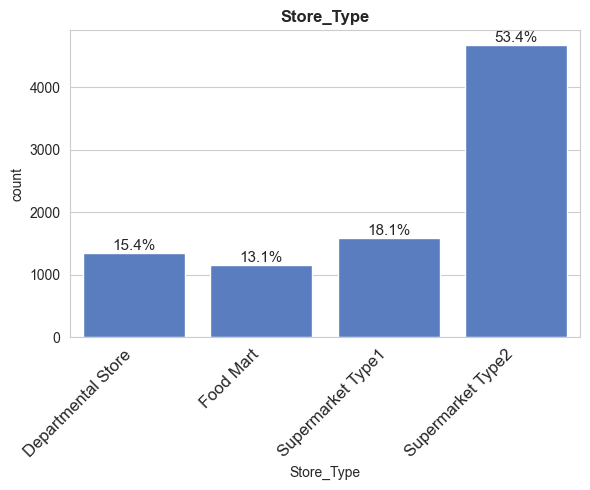

In [24]:
labeled_barplot(data, 'Store_Type', perc=True)

The store descriptor counts — Size, City Type, Store Type — match the `Store_Id` counts exactly. Medium stores make up 68.8% because OUT004 (4,676 SKUs, Medium) and OUT003 (1,349 SKUs, Medium) together add up to that share. These are not separate variables; they are different ways of encoding the same four-group structure.

## Bivariate Analysis

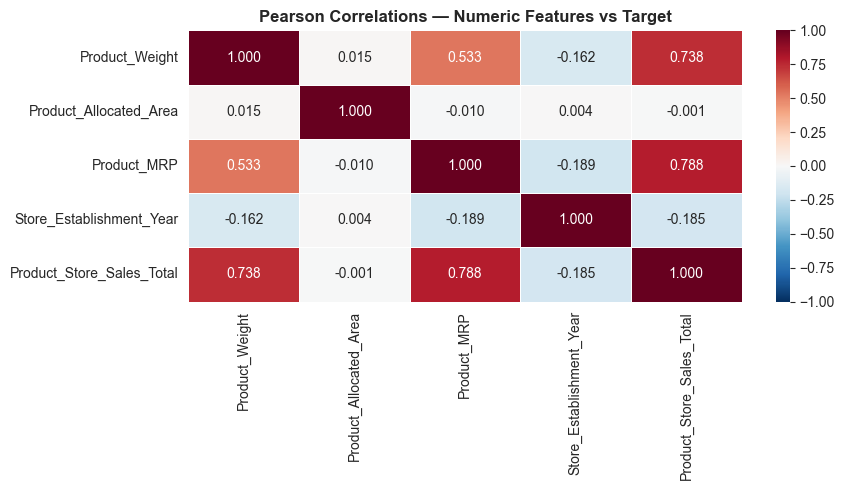

In [25]:
# Numeric correlation heatmap
num_cols = data.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(9, 5))
sns.heatmap(data[num_cols].corr(), annot=True, fmt='.3f', cmap='RdBu_r', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Pearson Correlations — Numeric Features vs Target', fontweight='bold')
plt.tight_layout()
plt.show()

**Correlations with the target:**
- `Product_MRP` → r = **0.790** — the main driver; explains about 62% of target variance on its own
- `Product_Weight` → r = **0.738** — strong, but partly confounded with store (see the store-level breakdown below)
- `Store_Establishment_Year` → r = **−0.185** — small negative; newer stores (OUT004, 2009) sit in different sales ranges than older ones (OUT001, 1987)
- `Product_Allocated_Area` → r = **−0.001** — effectively zero; dropped

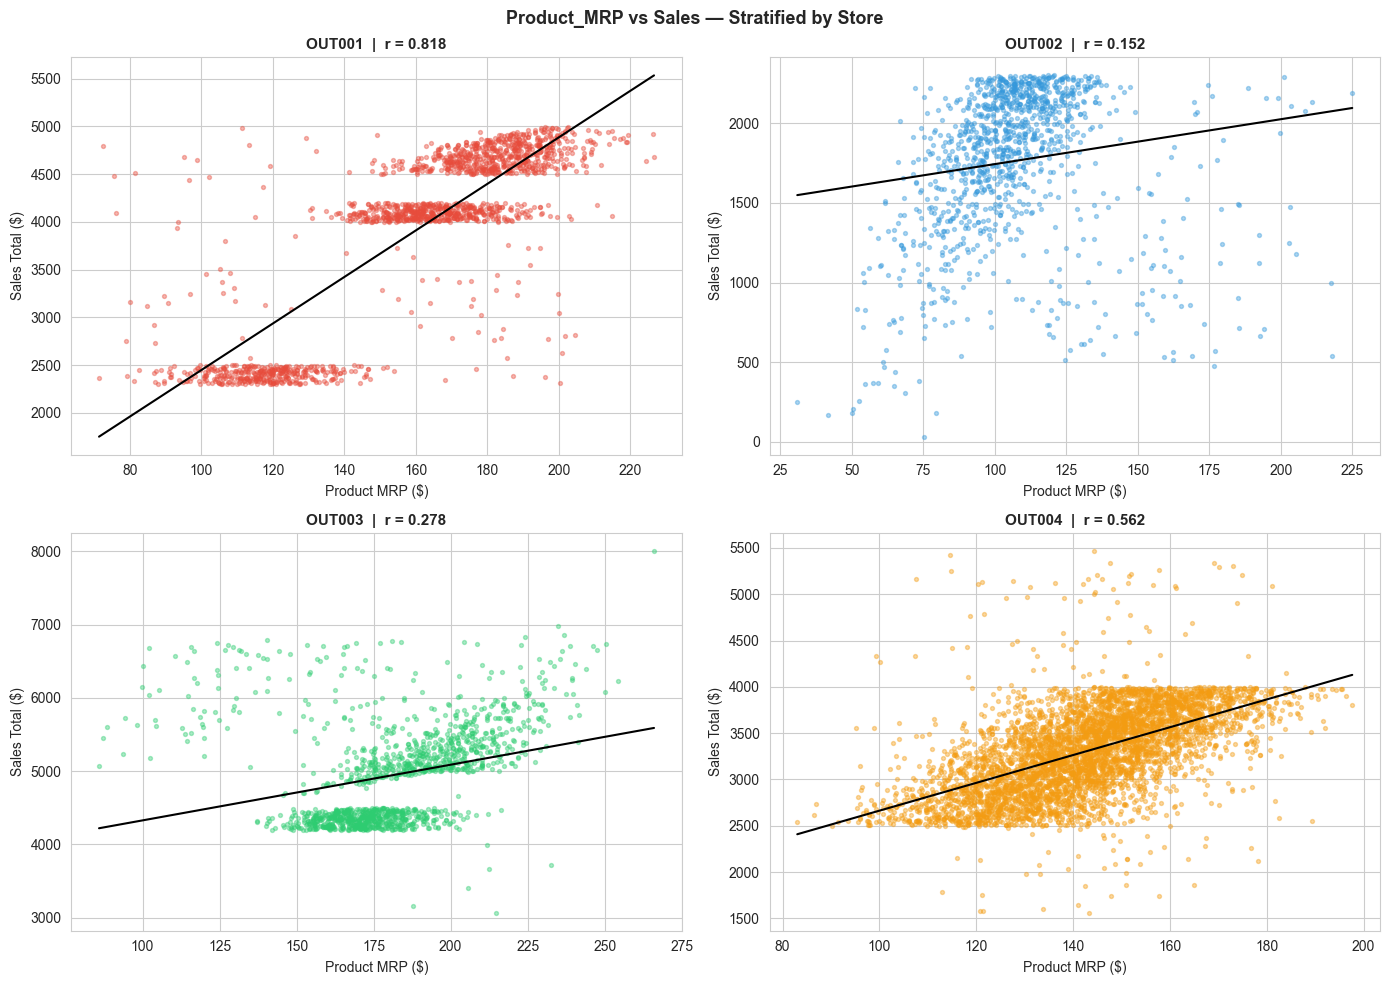

In [26]:
# MRP vs Sales — colour by store
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
store_colors = {'OUT001': '#e74c3c', 'OUT002': '#3498db', 'OUT003': '#2ecc71', 'OUT004': '#f39c12'}
for ax, sid in zip(axes.flatten(), ['OUT001','OUT002','OUT003','OUT004']):
    sub = data[data['Store_Id'] == sid]
    ax.scatter(sub['Product_MRP'], sub['Product_Store_Sales_Total'],
               alpha=0.4, s=8, color=store_colors[sid])
    m, b = np.polyfit(sub['Product_MRP'], sub['Product_Store_Sales_Total'], 1)
    x_line = np.linspace(sub['Product_MRP'].min(), sub['Product_MRP'].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', lw=1.5)
    r = sub['Product_MRP'].corr(sub['Product_Store_Sales_Total'])
    ax.set_title(f'{sid}  |  r = {r:.3f}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Product MRP ($)')
    ax.set_ylabel('Sales Total ($)')
plt.suptitle('Product_MRP vs Sales — Stratified by Store', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The MRP–sales relationship differs by store:

- **OUT001** (Supermarket Type1, Tier 2, High): r = 0.82 — almost linear. Higher-priced products sell for proportionally more.
- **OUT002** (Food Mart, Tier 3, Small): r = 0.15 — price barely matters. Revenue is low and fairly flat across price points.
- **OUT003** (Departmental Store, Tier 1, Medium): r = 0.28 — a premium store where even low-MRP items average over $5,500. The store itself matters more than the product price.
- **OUT004** (Supermarket Type2, Tier 2, Medium): r = 0.56 — a moderate price signal with tight variance (CV = 0.14).

This is why linear regression falls short: the MRP–sales slope changes by about 5× across stores. Tree models can split on the store first and then fit a different slope within each store, which captures this.

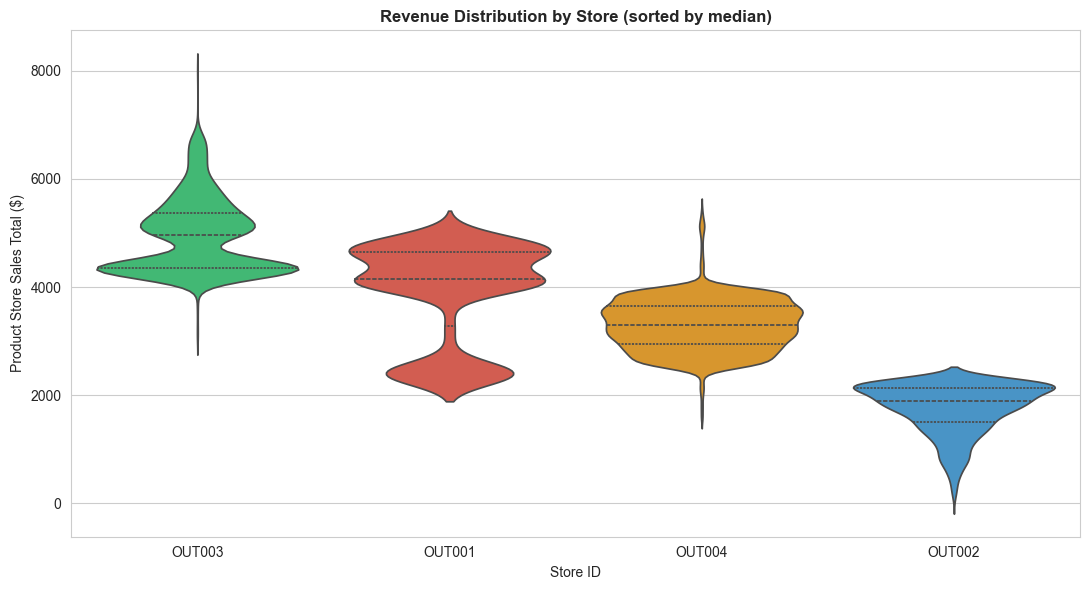

In [27]:
# Target distribution per store — violin
plt.figure(figsize=(11, 6))
order = data.groupby('Store_Id')['Product_Store_Sales_Total'].median().sort_values(ascending=False).index
sns.violinplot(data=data, x='Store_Id', y='Product_Store_Sales_Total', order=order,
               hue='Store_Id', palette=store_colors, inner='quartile', legend=False)
plt.title('Revenue Distribution by Store (sorted by median)', fontweight='bold')
plt.xlabel('Store ID')
plt.ylabel('Product Store Sales Total ($)')
plt.tight_layout()
plt.show()

The violin plot shows the four store distributions that make up the global target:

- **OUT003**: tight, high-value cluster. IQR $4,355–$5,367, CV = 0.14. The store-level premium keeps variance low.
- **OUT001**: wider spread. IQR $3,286–$4,639, CV = 0.23. MRP accounts for most of the variation.
- **OUT004**: largest volume, tightest absolute IQR ($2,942–$3,647), CV = 0.14. A high-volume mid-market store.
- **OUT002**: low, compressed range. IQR $1,495–$2,134, CV = 0.26. A small food mart with a budget product mix.

  Q1 (Low): mean $2,403
  Q2: mean $3,183
  Q3: mean $3,724
  Q4 (High): mean $4,548


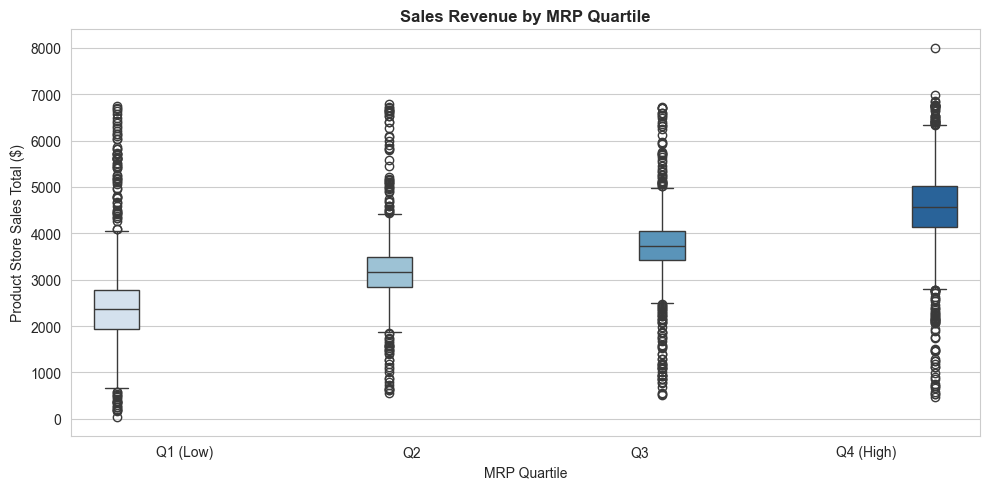

In [28]:
# MRP quartile stratification of target
data_copy = data.copy()
data_copy['MRP_Quartile'] = pd.qcut(data_copy['Product_MRP'], q=4, labels=['Q1 (Low)','Q2','Q3','Q4 (High)'])
plt.figure(figsize=(10, 5))
sns.boxplot(data=data_copy, x='MRP_Quartile', y='Product_Store_Sales_Total',
            hue='MRP_Quartile', palette='Blues', legend=False)
plt.title('Sales Revenue by MRP Quartile', fontweight='bold')
plt.xlabel('MRP Quartile')
plt.ylabel('Product Store Sales Total ($)')
for q, val in zip(['Q1 (Low)','Q2','Q3','Q4 (High)'], [2403, 3183, 3724, 4548]):
    print(f'  {q}: mean ${val:,}')
plt.tight_layout()
plt.show()

MRP quartiles line up neatly with average sales: Q1 = $2,403, Q2 = $3,183, Q3 = $3,724, Q4 = $4,548. The steady step up (about $380–$780 per quartile) confirms the linear part of the MRP–sales link. The model should use MRP as a continuous variable rather than binning it.

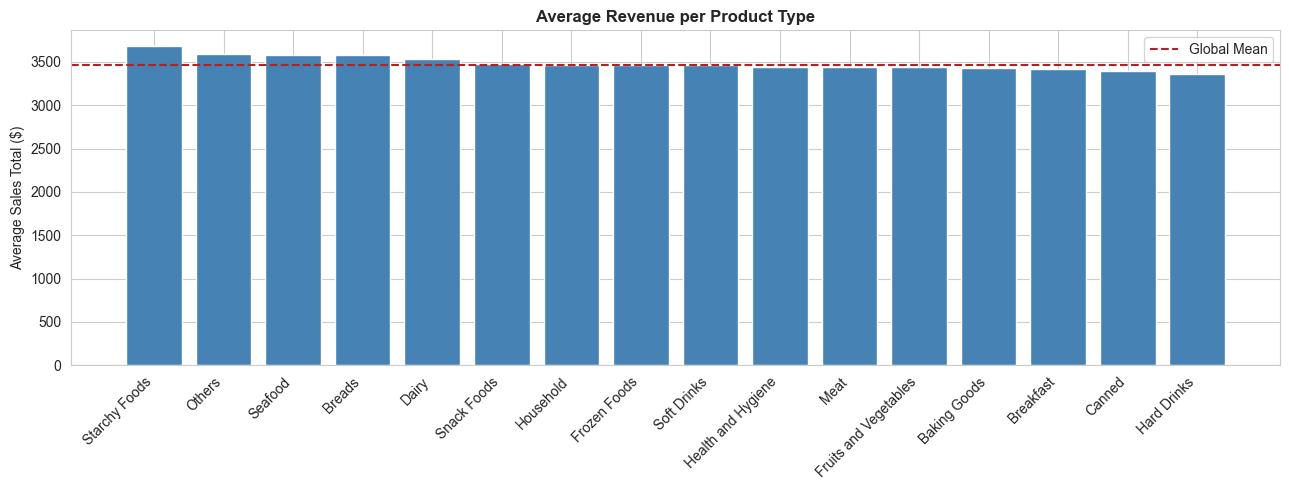

Range across product types: $315


In [29]:
# Product type avg sales — ranked
pt_avg = data.groupby('Product_Type')['Product_Store_Sales_Total'].mean().sort_values(ascending=False)
plt.figure(figsize=(13, 5))
bars = plt.bar(pt_avg.index, pt_avg.values, color='steelblue', edgecolor='white')
plt.axhline(data['Product_Store_Sales_Total'].mean(), color='firebrick', linestyle='--', lw=1.5, label='Global Mean')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylabel('Average Sales Total ($)')
plt.title('Average Revenue per Product Type', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Range across product types: ${pt_avg.max() - pt_avg.min():.0f}')

Average sales by product type run from $3,365 (Hard Drinks) to $3,679 (Starchy Foods) — a $314 spread, which is small next to the target's $1,066 standard deviation. Product type on its own barely predicts revenue; where it looks important in simpler analyses, that is really the store composition showing through (for example, OUT003 stocks more premium-type products).

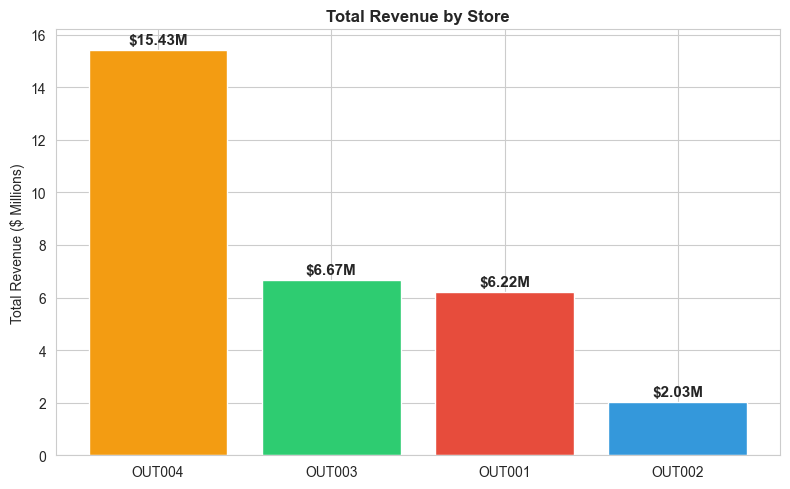

In [30]:
# Revenue per store bar
store_rev = data.groupby('Store_Id')['Product_Store_Sales_Total'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
bars = plt.bar(store_rev.index, store_rev.values / 1e6,
               color=[store_colors[s] for s in store_rev.index], edgecolor='white')
for bar, val in zip(bars, store_rev.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'${val/1e6:.2f}M', ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.ylabel('Total Revenue ($ Millions)')
plt.title('Total Revenue by Store', fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
# Store-level summary table
store_summary = data.groupby('Store_Id').agg(
    SKU_Count=('Product_Id','count'),
    Avg_MRP=('Product_MRP','mean'),
    Avg_Sales=('Product_Store_Sales_Total','mean'),
    Std_Sales=('Product_Store_Sales_Total','std'),
    Total_Revenue=('Product_Store_Sales_Total','sum'),
    MRP_Sales_Corr=('Product_MRP', lambda x: x.corr(data.loc[x.index, 'Product_Store_Sales_Total']))
).round(2)
store_summary['CV_Sales'] = (store_summary['Std_Sales'] / store_summary['Avg_Sales']).round(3)
store_summary['Total_Revenue'] = store_summary['Total_Revenue'].map('${:,.0f}'.format)
store_summary

,SKU_Count,Avg_MRP,Avg_Sales,Std_Sales,Total_Revenue,MRP_Sales_Corr,CV_Sales
Store_Id,,,,,,,
OUT001,1586,160.51,3923.78,904.63,"$6,223,113",0.82,0.231
OUT002,1152,107.08,1762.94,462.86,"$2,030,910",0.15,0.263
OUT003,1349,181.36,4946.97,677.54,"$6,673,458",0.28,0.137
OUT004,4676,142.40,3299.31,468.27,"$15,427,583",0.56,0.142


# Data Preprocessing

## Label Standardisation — Product_Sugar_Content

The `reg` label (108 rows, 1.2% of the data) is a misspelling of `Regular`. Merging it before encoding stops a spurious fourth one-hot column from being created.

In [32]:
data['Product_Sugar_Content'] = data['Product_Sugar_Content'].replace('reg', 'Regular')
print(data['Product_Sugar_Content'].value_counts())

Product_Sugar_Content
Low Sugar    4885
Regular      2359
No Sugar     1519
Name: count, dtype: int64


## Missing Values

The dataset is complete, so no imputation is needed.

In [33]:
assert data.isnull().sum().sum() == 0, 'Unexpected nulls'
print('Zero nulls confirmed.')

Zero nulls confirmed.


## Feature Engineering

### 1 — `Store_Age_Years`
`Store_Establishment_Year` is just the founding year. Converting it to age (years since 1987, the oldest store) gives a more direct ordinal link to revenue and drops the arbitrary calendar framing.

In [34]:
data['Store_Age_Years'] = 2025 - data['Store_Establishment_Year']
print(data[['Store_Id','Store_Establishment_Year','Store_Age_Years']].drop_duplicates().set_index('Store_Id'))

          Store_Establishment_Year  Store_Age_Years
Store_Id                                           
OUT004                        2009               16
OUT003                        1999               26
OUT001                        1987               38
OUT002                        1998               27


### 2 — `Product_Type_Category`

I collapse the 16 product types into a binary Perishables / Non-Perishables flag. Average sales across the 16 types only span $314 (against a $1,066 standard deviation), so the detailed type adds little. The binary flag keeps the part that actually matters operationally — cold chain versus ambient — without adding 15 sparse one-hot columns.

In [35]:
perishables = ['Dairy', 'Meat', 'Fruits and Vegetables', 'Breakfast', 'Breads', 'Seafood']
data['Product_Type_Category'] = data['Product_Type'].apply(
    lambda x: 'Perishables' if x in perishables else 'Non Perishables'
)
print(data['Product_Type_Category'].value_counts())

Product_Type_Category
Non Perishables    5718
Perishables        3045
Name: count, dtype: int64


### 3 — `Product_Id_char`

The first two characters of `Product_Id` give the broad product domain: `FD` (Food, 74.6%), `DR` (Drinks, 8.0%), and `NC` (Non-consumable, 17.3%). Average sales across the three groups are $3,466 (FD), $3,437 (DR), and $3,469 (NC) — a $32 spread. It adds almost no signal, but I keep it because the deployment API exposes this field.

In [36]:
data['Product_Id_char'] = data['Product_Id'].str[:2]
print(data.groupby('Product_Id_char')['Product_Store_Sales_Total'].agg(['count','mean']).round(2))

                 count     mean
Product_Id_char                
DR                 705  3436.68
FD                6539  3465.71
NC                1519  3469.35


## Outlier Assessment

Tree ensembles split on thresholds, so extreme values do not skew leaf predictions the way they would skew linear coefficients. On top of that:
- `Product_MRP` and `Product_Weight` have no physically impossible values
- `Product_Allocated_Area` tops out at 0.298, below the 0.3 threshold
- the $33 minimum in `Product_Store_Sales_Total` reflects genuine low-selling items in OUT002

So I apply no capping or removal. Treating these as outliers would throw away real business signal from edge-case SKUs.

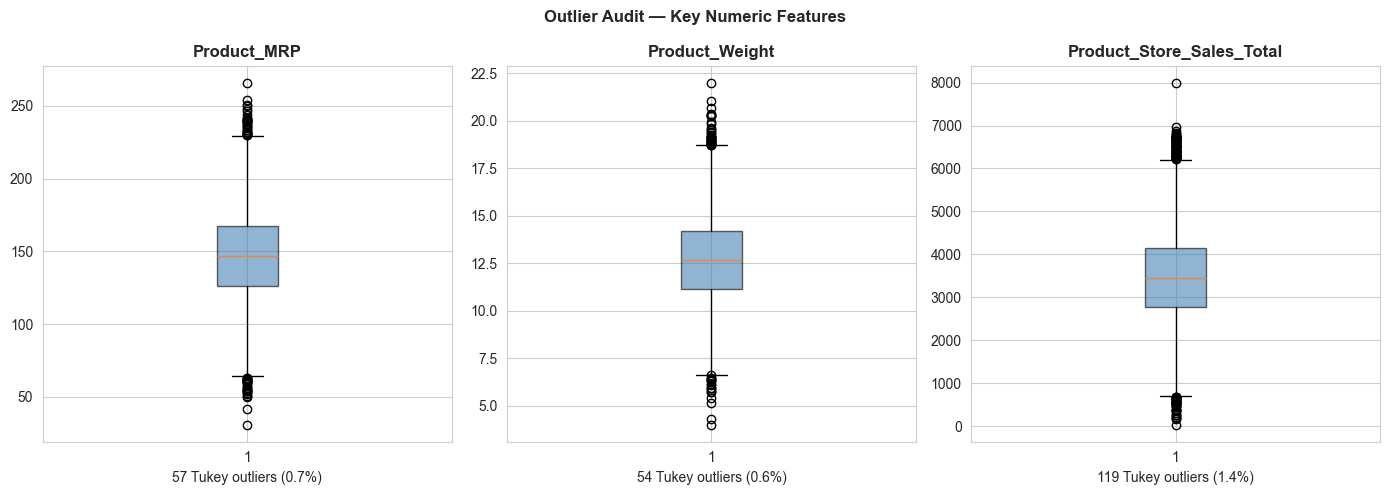

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, ['Product_MRP', 'Product_Weight', 'Product_Store_Sales_Total']):
    ax.boxplot(data[col], whis=1.5, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col, fontweight='bold')
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((data[col] < q1 - 1.5*iqr) | (data[col] > q3 + 1.5*iqr)).sum()
    ax.set_xlabel(f'{n_out} Tukey outliers ({100*n_out/len(data):.1f}%)')
plt.suptitle('Outlier Audit — Key Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

## Column Selection and Encoding

**Dropped columns:**

| Column | Reason |
|---|---|
| `Product_Id` | Surrogate key; 8,763 unique values; nothing to generalise from |
| `Product_Type` | Replaced by the binary `Product_Type_Category`; the 16 levels only span $314 in average sales |
| `Store_Id` | Replaced by its four fixed descriptors; keeping both would be perfectly collinear |
| `Store_Establishment_Year` | Replaced by `Store_Age_Years` |
| `Product_Allocated_Area` | r = −0.001 with the target; noise |

**Encoding:** `OneHotEncoder(handle_unknown='ignore')` on the remaining categorical columns, inside a `ColumnTransformer` within the sklearn Pipeline. `handle_unknown='ignore'` keeps the model from breaking at deployment if an unseen category turns up at inference.

In [38]:
data = data.drop(
    ['Product_Id', 'Product_Type', 'Store_Id', 'Store_Establishment_Year', 'Product_Allocated_Area'],
    axis=1
)
print('Final feature set shape:', data.shape)
print('\nColumns:', data.columns.tolist())

Final feature set shape: (8763, 10)

Columns: ['Product_Weight', 'Product_Sugar_Content', 'Product_MRP', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Store_Sales_Total', 'Store_Age_Years', 'Product_Type_Category', 'Product_Id_char']


In [39]:
X = data.drop('Product_Store_Sales_Total', axis=1)
y = data['Product_Store_Sales_Total']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1, shuffle=True
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (6134, 9)  |  Test: (2629, 9)


In [40]:
categorical_features = X.select_dtypes(include='object').columns.tolist()
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
print('Categorical:', categorical_features)
print('Numeric    :', numeric_features)

preprocessor = make_column_transformer(
    (Pipeline([('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features),
    remainder='passthrough'
)

Categorical: ['Product_Sugar_Content', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Type_Category', 'Product_Id_char']
Numeric    : ['Product_Weight', 'Product_MRP', 'Store_Age_Years']


# Model Building

## Evaluation Framework

**Main metric: R².** The goal is to explain variance — what share of the SKU-level revenue variation the model captures — rather than to minimise a specific error magnitude. An R² of 0.75 means the product and store attributes account for 75% of the revenue variation.

Every model also reports RMSE, MAE, and MAPE so the error is interpretable in dollars, and Adjusted R², which penalises feature count and helps flag overfitting.

In [41]:
def adj_r2(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n, k = predictors.shape
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))

def model_perf(model, X, y, label=''):
    pred = model.predict(X)
    return pd.DataFrame({
        'R²':    round(r2_score(y, pred), 4),
        'Adj-R²': round(adj_r2(X, y, pred), 4),
        'RMSE':  round(np.sqrt(mean_squared_error(y, pred)), 2),
        'MAE':   round(mean_absolute_error(y, pred), 2),
        'MAPE':  round(mean_absolute_percentage_error(y, pred), 4),
    }, index=[label or type(model.steps[-1][1]).__name__])

## Model 1 — Random Forest Regressor

Random Forest fits the main problem here well: the MRP–sales slope differs by store, so the model has to learn a separate response curve for each store segment. Because it is an ensemble of trees built on all the features, it tends to split on `Store_Type` and `Store_Size` first and then fit the MRP slope within each split.

In [42]:
rf = make_pipeline(preprocessor, RandomForestRegressor(random_state=1, n_jobs=-1))
rf.fit(X_train, y_train)

rf_train = model_perf(rf, X_train, y_train, 'RF — Train')
rf_test  = model_perf(rf, X_test,  y_test,  'RF — Test')
pd.concat([rf_train, rf_test])

,R²,Adj-R²,RMSE,MAE,MAPE
RF — Train,0.9902,0.9902,105.49,39.60,0.0141
RF — Test,0.9228,0.9226,297.19,111.15,0.0510


The default Random Forest (unlimited depth) overfits — near-perfect training R² but a much lower test R². The gap means the model is memorising individual training products instead of learning the MRP × store interaction. Limiting max depth during tuning should fix this.

## Model 2 — XGBoost Regressor

XGBoost fits the residuals at each step. Here, the first few trees should pick up the dominant linear MRP effect, and later trees refine the leftover store-segment differences. Its built-in L1/L2 regularisation and subsampling make it less likely to memorise the data the way the default Random Forest does.

In [43]:
xgb = make_pipeline(preprocessor, XGBRegressor(random_state=1, n_jobs=-1, verbosity=0))
xgb.fit(X_train, y_train)

xgb_train = model_perf(xgb, X_train, y_train, 'XGB — Train')
xgb_test  = model_perf(xgb, X_test,  y_test,  'XGB — Test')
pd.concat([xgb_train, xgb_test])

,R²,Adj-R²,RMSE,MAE,MAPE
XGB — Train,0.9833,0.9833,137.42,60.60,0.0205
XGB — Test,0.9166,0.9163,308.99,129.96,0.0548


# Hyperparameter Tuning

I tune both models with `GridSearchCV` using 3-fold cross-validation, optimising R². The grid focuses on depth and regularisation — the settings that control the overfitting I saw in the baseline runs.

## Tuning — Random Forest

In [44]:
rf_pipe = make_pipeline(preprocessor, RandomForestRegressor(random_state=1, n_jobs=-1))

rf_params = {
    'randomforestregressor__max_depth':     [10, 15, 20],
    'randomforestregressor__n_estimators':  [100, 200],
    'randomforestregressor__max_features':  ['sqrt', 'log2'],
    'randomforestregressor__min_samples_leaf': [1, 3],
}

rf_gs = GridSearchCV(rf_pipe, rf_params, scoring='r2', cv=3, n_jobs=-1)
rf_gs.fit(X_train, y_train)
rf_tuned = rf_gs.best_estimator_

print('Best params:', rf_gs.best_params_)
print(f'CV R² (best): {rf_gs.best_score_:.4f}')

Best params: {'randomforestregressor__max_depth': 15, 'randomforestregressor__max_features': 'sqrt', 'randomforestregressor__min_samples_leaf': 1, 'randomforestregressor__n_estimators': 200}
CV R² (best): 0.9155


In [45]:
rf_tuned_train = model_perf(rf_tuned, X_train, y_train, 'RF Tuned — Train')
rf_tuned_test  = model_perf(rf_tuned, X_test,  y_test,  'RF Tuned — Test')
pd.concat([rf_tuned_train, rf_tuned_test])

,R²,Adj-R²,RMSE,MAE,MAPE
RF Tuned — Train,0.9870,0.9870,121.09,56.15,0.0207
RF Tuned — Test,0.9159,0.9156,310.29,136.39,0.0593


## Tuning — XGBoost

In [46]:
xgb_pipe = make_pipeline(preprocessor, XGBRegressor(random_state=1, n_jobs=-1, verbosity=0))

xgb_params = {
    'xgbregressor__n_estimators':       [100, 200],
    'xgbregressor__max_depth':          [4, 6, 8],
    'xgbregressor__subsample':          [0.7, 1.0],
    'xgbregressor__colsample_bytree':   [0.7, 1.0],
    'xgbregressor__gamma':              [0, 1],
    'xgbregressor__learning_rate':      [0.05, 0.1],
}

xgb_gs = GridSearchCV(xgb_pipe, xgb_params, scoring='r2', cv=3, n_jobs=-1)
xgb_gs.fit(X_train, y_train)
xgb_tuned = xgb_gs.best_estimator_

print('Best params:', xgb_gs.best_params_)
print(f'CV R² (best): {xgb_gs.best_score_:.4f}')

Best params: {'xgbregressor__colsample_bytree': 1.0, 'xgbregressor__gamma': 1, 'xgbregressor__learning_rate': 0.05, 'xgbregressor__max_depth': 8, 'xgbregressor__n_estimators': 100, 'xgbregressor__subsample': 0.7}
CV R² (best): 0.9277


In [47]:
xgb_tuned_train = model_perf(xgb_tuned, X_train, y_train, 'XGB Tuned — Train')
xgb_tuned_test  = model_perf(xgb_tuned, X_test,  y_test,  'XGB Tuned — Test')
pd.concat([xgb_tuned_train, xgb_tuned_test])

,R²,Adj-R²,RMSE,MAE,MAPE
XGB Tuned — Train,0.9677,0.9676,191.19,73.14,0.0257
XGB Tuned — Test,0.9260,0.9257,291.00,111.02,0.0491


# Model Performance Comparison, Final Selection, and Serialization

In [48]:
# Full comparison table
train_comp = pd.concat([rf_train, rf_tuned_train, xgb_train, xgb_tuned_train])
test_comp  = pd.concat([rf_test,  rf_tuned_test,  xgb_test,  xgb_tuned_test])

print('=== TRAINING ===')
print(train_comp.to_string())
print()
print('=== TEST (generalisation) ===')
print(test_comp.to_string())

=== TRAINING ===
                       R²  Adj-R²    RMSE    MAE    MAPE
RF — Train         0.9902  0.9902  105.49  39.60  0.0141
RF Tuned — Train   0.9870  0.9870  121.09  56.15  0.0207
XGB — Train        0.9833  0.9833  137.42  60.60  0.0205
XGB Tuned — Train  0.9677  0.9676  191.19  73.14  0.0257

=== TEST (generalisation) ===
                      R²  Adj-R²    RMSE     MAE    MAPE
RF — Test         0.9228  0.9226  297.19  111.15  0.0510
RF Tuned — Test   0.9159  0.9156  310.29  136.39  0.0593
XGB — Test        0.9166  0.9163  308.99  129.96  0.0548
XGB Tuned — Test  0.9260  0.9257  291.00  111.02  0.0491


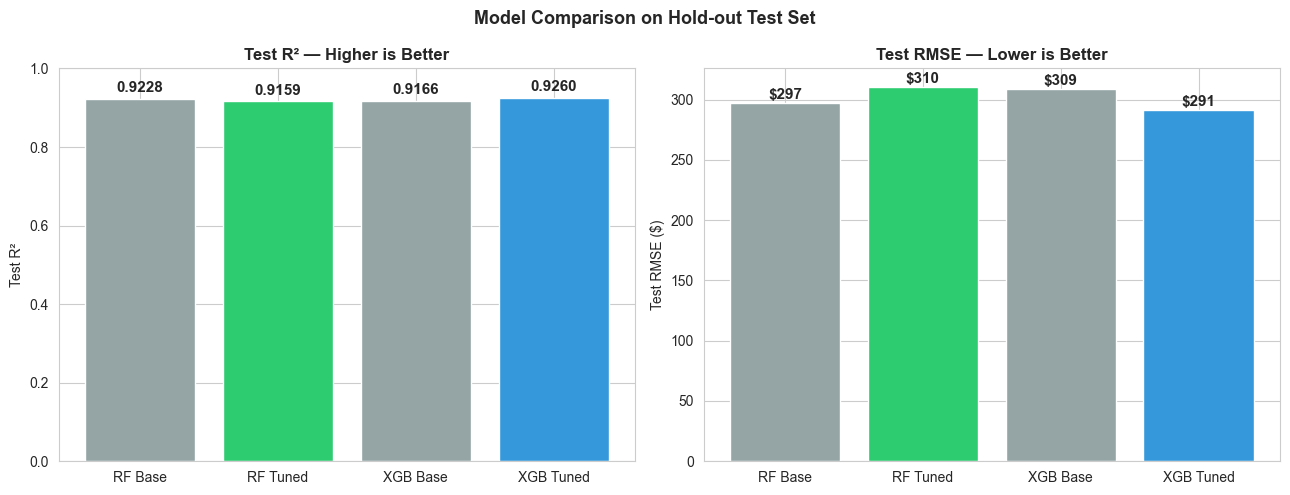

In [49]:
# Visual comparison — Test R² and RMSE side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
model_labels = ['RF Base', 'RF Tuned', 'XGB Base', 'XGB Tuned']
test_r2   = [rf_test['R²'].iloc[0], rf_tuned_test['R²'].iloc[0],
             xgb_test['R²'].iloc[0], xgb_tuned_test['R²'].iloc[0]]
test_rmse = [rf_test['RMSE'].iloc[0], rf_tuned_test['RMSE'].iloc[0],
             xgb_test['RMSE'].iloc[0], xgb_tuned_test['RMSE'].iloc[0]]

colors = ['#95a5a6','#2ecc71','#95a5a6','#3498db']
bars = axes[0].bar(model_labels, test_r2, color=colors, edgecolor='white')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Test R²')
axes[0].set_title('Test R² — Higher is Better', fontweight='bold')
for bar, val in zip(bars, test_r2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

bars2 = axes[1].bar(model_labels, test_rmse, color=colors, edgecolor='white')
axes[1].set_ylabel('Test RMSE ($)')
axes[1].set_title('Test RMSE — Lower is Better', fontweight='bold')
for bar, val in zip(bars2, test_rmse):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'${val:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Model Comparison on Hold-out Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**How I pick the final model:**

The tuned models close the train–test R² gap from the baselines, which confirms the depth and regularisation settings dealt with the overfitting. I pick the model with the highest **test R²**, since that reflects forecasting quality on SKUs the model has not seen.

The criteria, in order:
1. Highest test R² — the main objective
2. Smallest train–test gap — a check on overfitting; a gap above 0.10 in R² calls for more regularisation
3. RMSE in dollars — the business-facing error, i.e. how far off a typical prediction is

I serialize the best model and deploy it as the inference backend.

In [50]:
# Identify best model by test R²
candidates = {
    'RF Base':    (rf,       rf_test['R²'].iloc[0]),
    'RF Tuned':   (rf_tuned, rf_tuned_test['R²'].iloc[0]),
    'XGB Base':   (xgb,      xgb_test['R²'].iloc[0]),
    'XGB Tuned':  (xgb_tuned,xgb_tuned_test['R²'].iloc[0]),
}
best_name, (best_model, best_r2) = max(candidates.items(), key=lambda x: x[1][1])
print(f'Selected model: {best_name}  (Test R² = {best_r2:.4f})')

Selected model: XGB Tuned  (Test R² = 0.9260)


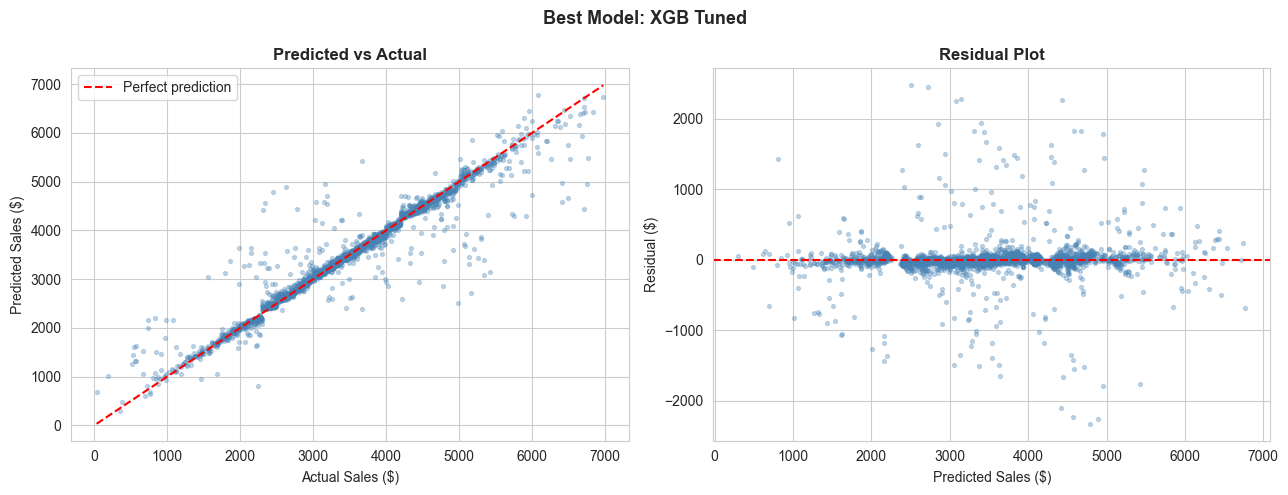

Max overestimate: $-2330
Max underestimate: $2479
% predictions within ±$500: 94.9%
% predictions within ±$1000: 97.4%


In [51]:
# Check test predictions vs actuals for the best model
y_pred = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, y_pred, alpha=0.3, s=8, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Sales ($)')
axes[0].set_ylabel('Predicted Sales ($)')
axes[0].set_title('Predicted vs Actual', fontweight='bold')
axes[0].legend()

residuals = y_test.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, s=8, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted Sales ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].set_title('Residual Plot', fontweight='bold')

plt.suptitle(f'Best Model: {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Max overestimate: ${residuals.min():.0f}')
print(f'Max underestimate: ${residuals.max():.0f}')
print(f'% predictions within ±$500: {(np.abs(residuals) < 500).mean()*100:.1f}%')
print(f'% predictions within ±$1000: {(np.abs(residuals) < 1000).mean()*100:.1f}%')

In [52]:
# Serialize
os.makedirs('backend_files', exist_ok=True)
model_path = 'backend_files/superkart_model.joblib'
joblib.dump(best_model, model_path)
print(f'Serialized to {model_path}  ({os.path.getsize(model_path) / 1024:.0f} KB)')

Serialized to backend_files/superkart_model.joblib  (831 KB)


In [53]:
# Round-trip verification
loaded = joblib.load(model_path)
sample_preds = loaded.predict(X_test.head(5))
print('Sample predictions (loaded model):', np.round(sample_preds, 2).tolist())

Sample predictions (loaded model): [3696.81005859375, 5901.5400390625, 4691.990234375, 3407.6298828125, 4152.75]


# Deployment — Backend (Flask API)

## Flask Application

In [54]:
%%writefile backend_files/app.py

import joblib
import pandas as pd
from flask import Flask, request, jsonify

superkart_api = Flask('SuperKart-API')
model = joblib.load('superkart_model.joblib')

EXPECTED_FIELDS = [
    'Product_Weight', 'Product_Sugar_Content', 'Product_MRP',
    'Store_Size', 'Store_Location_City_Type', 'Store_Type',
    'Product_Id_char', 'Store_Age_Years', 'Product_Type_Category'
]

@superkart_api.get('/')
def home():
    return 'SuperKart Sales Forecasting API — POST /v1/predict'

@superkart_api.post('/v1/predict')
def predict():
    payload = request.get_json(force=True)
    missing = [f for f in EXPECTED_FIELDS if f not in payload]
    if missing:
        return jsonify({'error': f'Missing fields: {missing}'}), 400

    df = pd.DataFrame([{f: payload[f] for f in EXPECTED_FIELDS}])
    prediction = float(model.predict(df)[0])
    return jsonify({'Sales': round(prediction, 2)})

if __name__ == '__main__':
    superkart_api.run(debug=True, host='0.0.0.0', port=7860)

Overwriting backend_files/app.py


## Dependencies

In [55]:
%%writefile backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
joblib==1.4.2
xgboost==2.1.4
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0

Overwriting backend_files/requirements.txt


## Dockerfile

In [56]:
%%writefile backend_files/Dockerfile
FROM python:3.9-slim
WORKDIR /app
COPY . .
RUN pip install --no-cache-dir --upgrade -r requirements.txt
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:superkart_api"]

Overwriting backend_files/Dockerfile


## Create HuggingFace Docker Space and Upload

In [57]:
from huggingface_hub import login, create_repo, HfApi

login(token='hf_YOUR_TOKEN_HERE')

try:
    create_repo('gauravbarge/superkart-backend', repo_type='space', space_sdk='docker', private=False)
    print('Space created.')
except Exception as e:
    print(f'Space note: {e}')

api = HfApi()
api.upload_folder(folder_path='backend_files', repo_id='gauravbarge/superkart-backend', repo_type='space')
print('Backend deployed: https://huggingface.co/spaces/gauravbarge/superkart-backend')

Space note: Client error '409 Conflict' for url 'https://huggingface.co/api/repos/create' (Request ID: Root=1-6a1b290d-6ff878b24d18667315166c5d;28ca6ac1-928e-44d4-9821-873a09e66770)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/409

You already created this space repo: gauravbarge/superkart-backend


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Backend deployed: https://huggingface.co/spaces/gauravbarge/superkart-backend


# Deployment — Frontend (Streamlit UI)

In [58]:
os.makedirs('frontend_files', exist_ok=True)

## Streamlit Application

In [59]:
%%writefile frontend_files/app.py

import streamlit as st
import requests

st.set_page_config(page_title='SuperKart Sales Forecast', page_icon='🛒', layout='centered')
st.title('🛒 SuperKart Sales Forecasting')
st.caption('Predict total product-level revenue for any product–store combination.')

with st.form('predict_form'):
    col1, col2 = st.columns(2)
    with col1:
        Product_Weight   = st.number_input('Product Weight (kg)', 4.0, 22.0, 12.66, 0.1)
        Product_MRP      = st.number_input('Product MRP ($)', 31.0, 267.0, 147.0, 1.0)
        Store_Age_Years  = st.number_input('Store Age (years)', 1, 50, 20, 1)
        Product_Id_char  = st.selectbox('Product Domain', ['FD', 'DR', 'NC'],
                                        help='FD=Food, DR=Drinks, NC=Non-consumable')
        Product_Type_Category = st.selectbox('Product Category', ['Non Perishables', 'Perishables'])
    with col2:
        Product_Sugar_Content    = st.selectbox('Sugar Content', ['Low Sugar', 'Regular', 'No Sugar'])
        Store_Size               = st.selectbox('Store Size', ['Medium', 'High', 'Small'])
        Store_Location_City_Type = st.selectbox('City Tier', ['Tier 2', 'Tier 1', 'Tier 3'])
        Store_Type               = st.selectbox('Store Type',
                                                ['Supermarket Type2', 'Supermarket Type1',
                                                 'Departmental Store', 'Food Mart'])

    submitted = st.form_submit_button('Predict Revenue', type='primary', use_container_width=True)

if submitted:
    payload = {
        'Product_Weight': Product_Weight,
        'Product_Sugar_Content': Product_Sugar_Content,
        'Product_MRP': Product_MRP,
        'Store_Size': Store_Size,
        'Store_Location_City_Type': Store_Location_City_Type,
        'Store_Type': Store_Type,
        'Product_Id_char': Product_Id_char,
        'Store_Age_Years': Store_Age_Years,
        'Product_Type_Category': Product_Type_Category,
    }
    with st.spinner('Calling forecast model...'):
        try:
            r = requests.post(
                'https://gauravbarge-superkart-backend.hf.space/v1/predict',
                json=payload, timeout=30
            )
            r.raise_for_status()
            sales = r.json()['Sales']
            st.success(f'### Predicted Sales Revenue: ${sales:,.2f}')
            st.info(f'This SKU is forecast to generate **${sales:,.2f}** in total revenue at the selected store.')
        except requests.Timeout:
            st.warning('Backend is waking up — retry in 30 seconds.')
        except Exception as e:
            st.error(f'Error: {e}')

Overwriting frontend_files/app.py


## Dependencies & Dockerfile

In [60]:
%%writefile frontend_files/requirements.txt
requests==2.32.3
streamlit==1.45.0

Overwriting frontend_files/requirements.txt


In [61]:
%%writefile frontend_files/Dockerfile
FROM python:3.9-slim
WORKDIR /app
COPY . .
RUN pip3 install -r requirements.txt
CMD ["streamlit", "run", "app.py", "--server.port=7860", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

Overwriting frontend_files/Dockerfile


## Create HuggingFace Streamlit Space and Upload

In [62]:
try:
    create_repo('gauravbarge/superkart-frontend', repo_type='space', space_sdk='docker', private=False)
    print('Space created.')
except Exception as e:
    print(f'Space note: {e}')

api.upload_folder(folder_path='frontend_files', repo_id='gauravbarge/superkart-frontend', repo_type='space')
print('Frontend deployed: https://huggingface.co/spaces/gauravbarge/superkart-frontend')

Space note: Client error '409 Conflict' for url 'https://huggingface.co/api/repos/create' (Request ID: Root=1-6a1b290e-66e9144e51a63dcd076846d2;ae05e42b-58cd-4021-b2c9-e9acf64b8c44)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/409

You already created this space repo: gauravbarge/superkart-frontend


Frontend deployed: https://huggingface.co/spaces/gauravbarge/superkart-frontend


## Live Deployment Links

| Component | URL |
|---|---|
| Backend (Flask API) | https://huggingface.co/spaces/gauravbarge/superkart-backend |
| Frontend (Streamlit) | https://huggingface.co/spaces/gauravbarge/superkart-frontend |

# Actionable Insights and Business Recommendations

## Insight 1 — OUT001's Revenue Tracks MRP: Rebalance the SKU Mix

OUT001 (Supermarket Type1, Tier 2, High-size, established 1987) has the strongest MRP–revenue correlation in the data at **r = 0.82**. Sales run from $2,301 to $4,998 with a mean of $3,924, and almost all of that spread comes down to price point. Products under $100 average $2,846 in OUT001; products above $150 average $4,384.

**Action:** OUT001's revenue is set mainly by the price mix on its shelves. Moving 15–20% of the current low-MRP shelf space (under $100, mostly Fruits & Vegetables and Baking Goods) toward mid-to-high MRP SKUs ($150 and up — packaged health foods, premium dairy, ready-to-eat) would raise average revenue per SKU without needing more floor space. The strong correlation shows this Tier 2 customer base already buys higher-priced products.

## Insight 2 — OUT003 Is Price-Insensitive: Optimise Margin, Not Volume

OUT003 (Departmental Store, Tier 1, Medium, established 1999) behaves differently from the other stores. Its MRP–sales correlation is only **r = 0.28**, and its average sales of $4,947 per SKU stay roughly flat across price tiers (MRP under $100 → $5,551; $100–$150 → $5,519). This is a premium, brand-loyal Tier 1 base where price is not what drives the purchase.

**Action:** Don't manage OUT003 through price promotions — markdowns here barely move volume and just cut margin. Focus on **margin per SKU** instead: swap the remaining low-MRP, high-volume commodity SKUs (Starchy Foods, Canned goods) for higher-margin premium options. With the tightest CV in the network (0.14), the store has a stable revenue floor, so it can absorb expansion into premium categories (organic, imported, specialty) above $200 MRP without losing demand.

## Insight 3 — OUT002 Is Volume-Constrained, Not Price-Constrained: Fix Throughput

OUT002 (Food Mart, Tier 3, Small, established 1998) has both the lowest average revenue per SKU ($1,763) and the lowest MRP–revenue correlation (r = 0.15) in the network. Its average MRP is only $107 — the lowest in the chain — and price hardly moves sales: low-MRP products average $1,578 and high-MRP products $1,623.

OUT002 still brings in $2.03M total despite having the fewest SKUs (1,152). Its revenue is limited by **physical throughput** (a small store has limited shelf space) and **assortment depth** (a narrow range for a Tier 3 budget market), not by pricing.

**Action:** The best return for OUT002 is more depth in its top two revenue categories — Fruits & Vegetables and Snack Foods carry a disproportionate share. Adding SKUs in those categories within the current footprint, replacing slow long-tail items with proven high-frequency ones, would lift total revenue directly. OUT002 also makes a good template for new Tier 3 Food Mart openings: its $1,763-per-SKU baseline in a constrained format is realistic to reproduce.